# De dónde sale el `EVIDENCE_SCORE` y qué forma tiene


In [ ]:
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pyarrow.compute as pc
import pyarrow.parquet as pq

#el cliente optimuskg descarga los parquet a este cache (es el mismo que usa loader/load_neo4j.py),
#pero su get_file consulta la API de Dataverse antes de mirar el cache y sin red falla, asi que se lee la ruta directamente
CACHE = Path.home() / ".cache" / "optimuskg" / "doi_10_7910_DVN_IYNGEV" / "2.0"
CAPAS = {
    "disease_gene": CACHE / "edges" / "disease_gene.parquet",
    "phenotype_gene": CACHE / "edges" / "phenotype_gene.parquet",
}
#las propiedades numericas que el paper lista para DIS - GEN para medir cuales estan pobladas
PROPIEDADES = ["evidence_score", "evidence_count", "evidence_index", "disgenet_score",
               "disease_specificity_index", "disease_pleiotropy_index", "number_of_pmids", "number_of_snps"]

for capa, ruta in CAPAS.items():
    print(f"{capa:16s} {pq.ParquetFile(ruta).metadata.num_rows:>10,} aristas")

Defaulting to user installation because normal site-packages is not writeable
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.1/50.1 MB 9.8 MB/s  0:00:056m0:00:0100:01

[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.
disease_gene      9,734,774 aristas
phenotype_gene      793,279 aristas


## qué contiene cada una

las 'ASSOCIATED_WITH' de gen y phenotype tienen la misma estructura

In [3]:
campos = {capa: [c.name for c in pq.ParquetFile(ruta).schema_arrow.field("properties").type]
          for capa, ruta in CAPAS.items()}
for capa, lista in campos.items():
    print(f"{capa}: {lista}")
assert campos["disease_gene"] == campos["phenotype_gene"]

disease_gene: ['evidence_score', 'evidence_count', 'disease_specificity_index', 'disease_pleiotropy_index', 'evidence_index', 'disgenet_score', 'year_initial', 'year_final', 'number_of_pmids', 'number_of_snps', 'sources']
phenotype_gene: ['evidence_score', 'evidence_count', 'disease_specificity_index', 'disease_pleiotropy_index', 'evidence_index', 'disgenet_score', 'year_initial', 'year_final', 'number_of_pmids', 'number_of_snps', 'sources']


## De dónde sale cada arista

Cada arista trae `sources.direct`, la lista de fuentes primarias de las que salió, y `sources.indirect`, las fuentes upstream de esas. Se recorre cada parquet una sola vez por lotes, guardando en memoria solo los dos vectores numéricos que se usan después (`EVIDENC_SCORE` y `EVIDENCE_COUNT`) y contando el resto sobre la marcha

In [4]:
score, conteo_evidencia, fuentes_directas, nulos = {}, {}, {}, {}

for capa, ruta in CAPAS.items():
    pedazos_score, pedazos_conteo = [], []
    fuentes_directas[capa] = Counter()
    nulos[capa] = Counter()
    for lote in pq.ParquetFile(ruta).iter_batches(batch_size=500_000, columns=["properties"]):
        propiedades = lote.column("properties")
        pedazos_score.append(pc.struct_field(propiedades, "evidence_score").to_numpy(zero_copy_only=False))
        pedazos_conteo.append(pc.struct_field(propiedades, "evidence_count").to_numpy(zero_copy_only=False))
        for nombre in PROPIEDADES:
            nulos[capa][nombre] += pc.sum(pc.is_null(pc.struct_field(propiedades, nombre))).as_py() or 0
        directas = pc.struct_field(pc.struct_field(propiedades, "sources"), "direct").to_pylist()
        fuentes_directas[capa].update(tuple(sorted(d or [])) for d in directas)
    score[capa] = np.concatenate(pedazos_score)
    conteo_evidencia[capa] = np.concatenate(pedazos_conteo)

n_aristas = {capa: len(score[capa]) for capa in CAPAS}

tabla_fuentes = pd.DataFrame({
    capa: {" + ".join(k): v for k, v in fuentes_directas[capa].items()} for capa in CAPAS
}).fillna(0).astype(int)
tabla_fuentes["% disease_gene"] = (100 * tabla_fuentes["disease_gene"] / n_aristas["disease_gene"]).round(2)
tabla_fuentes["% phenotype_gene"] = (100 * tabla_fuentes["phenotype_gene"] / n_aristas["phenotype_gene"]).round(2)
print("fuente directa de cada arista:")
display(tabla_fuentes)

tabla_nulos = pd.DataFrame({
    f"% nulo {capa}": {nombre: round(100 * nulos[capa][nombre] / n_aristas[capa], 1) for nombre in PROPIEDADES}
    for capa in CAPAS
})
print("propiedades de evidencia sin valor:")
display(tabla_nulos)

fuente directa de cada arista:


,disease_gene,phenotype_gene,% disease_gene,% phenotype_gene
OPEN_TARGETS,9709396,791962,99.74,99.83
DISGENET + OPEN_TARGETS,25378,1317,0.26,0.17


propiedades de evidencia sin valor:


,% nulo disease_gene,% nulo phenotype_gene
evidence_score,0.0,0.0
evidence_count,0.0,0.0
evidence_index,99.8,99.8
disgenet_score,99.7,99.8
disease_specificity_index,99.7,99.8
disease_pleiotropy_index,99.7,99.8
number_of_pmids,99.7,99.8
number_of_snps,99.7,99.8


En las dos capas más del 99,5% de las aristas tienen a Open Targets como única fuente directa, y las pocas que además vienen de disgenet nunca vienen de disgenet sola. `evidence_score` y `evidence_count` están en todas las aristas; `disgenet_score` y los índices de especificidad y pleiotropía, que son campos de disgenet, faltan en más del 99,5%. El `evidence_score` es el score de asociación global de Open Targets, en las dos capas

## forma de la distribución

Si las dos capas comparten generador y escala, sus distribuciones tienen que compartir dos huellas: el mismo rango y los mismos valores repetidos. Los valores repetidos aparecen porque una arista con una sola pieza de evidencia de un tipo dado recibe siempre el mismo número. Lo que sí puede diferir es la composición, o sea cuánta masa hay en cada tramo.

,disease_gene,phenotype_gene
aristas,9.734774e+06,793279.000000
minimo,9.095430e-04,0.001026
mediana,2.618327e-02,0.006877
p95,3.755045e-01,0.322021
p99,6.089415e-01,0.504244
maximo,9.485794e-01,0.865939
valores distintos,2.315593e+06,152494.000000


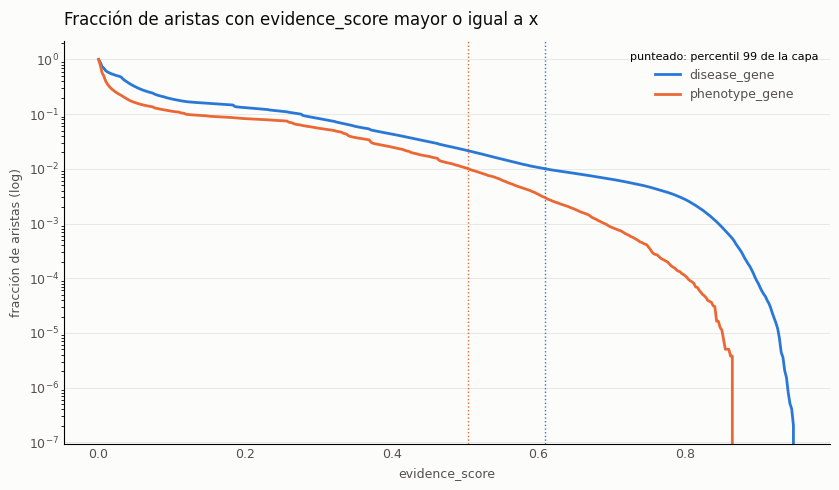

aristas que sobreviven a cada umbral:


,disease_gene,phenotype_gene,% disease_gene,% phenotype_gene
>= 0.1,1842190,89572,18.924,11.291
>= 0.2,1282590,65729,13.175,8.286
>= 0.3,810225,43920,8.323,5.537
>= 0.4,420400,19780,4.319,2.493
>= 0.5,215943,8326,2.218,1.050
>= 0.6,102708,2712,1.055,0.342
>= 0.7,62713,677,0.644,0.085
>= 0.8,26884,88,0.276,0.011
>= 0.9,770,0,0.008,0.000


In [5]:
UMBRALES = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]
percentil_99 = {capa: float(np.percentile(score[capa], 99)) for capa in CAPAS}

resumen = pd.DataFrame({
    capa: {
        "aristas": n_aristas[capa],
        "minimo": score[capa].min(),
        "mediana": np.median(score[capa]),
        "p95": np.percentile(score[capa], 95),
        "p99": percentil_99[capa],
        "maximo": score[capa].max(),
        "valores distintos": len(np.unique(score[capa])),
    } for capa in CAPAS
})
display(resumen)

COLORES = {"disease_gene": "#2a78d6", "phenotype_gene": "#eb6834"}
SUPERFICIE, TINTA, TINTA_SUAVE = "#fcfcfb", "#0b0b0b", "#52514e"

figura, ax = plt.subplots(figsize=(8.5, 5), facecolor=SUPERFICIE)
ax.set_facecolor(SUPERFICIE)
grilla = np.linspace(0, 0.95, 400)
for capa in CAPAS:
    ordenado = np.sort(score[capa])
    fraccion_sobre = 1 - np.searchsorted(ordenado, grilla, side="left") / len(ordenado)
    ax.plot(grilla, fraccion_sobre, color=COLORES[capa], linewidth=2, label=capa)
    ax.axvline(percentil_99[capa], color=COLORES[capa], linestyle=":", linewidth=1)
ax.set_yscale("log")
ax.set_title("Fracción de aristas con evidence_score mayor o igual a x", color=TINTA, fontsize=12, loc="left", pad=12)
ax.set_xlabel("evidence_score", color=TINTA_SUAVE, fontsize=9)
ax.set_ylabel("fracción de aristas (log)", color=TINTA_SUAVE, fontsize=9)
ax.grid(axis="y", color="#e5e5e2", linewidth=0.6)
ax.set_axisbelow(True)
for lado in ("top", "right"):
    ax.spines[lado].set_visible(False)
ax.tick_params(colors=TINTA_SUAVE, labelsize=9, length=0)
ax.legend(frameon=False, fontsize=9, labelcolor=TINTA_SUAVE, title="punteado: percentil 99 de la capa", title_fontsize=8)
plt.tight_layout()
plt.show()

tabla_umbrales = pd.DataFrame({
    capa: {f">= {u}": int((score[capa] >= u).sum()) for u in UMBRALES} for capa in CAPAS
})
for capa in CAPAS:
    tabla_umbrales[f"% {capa}"] = (100 * tabla_umbrales[capa] / n_aristas[capa]).round(3)
print("aristas que sobreviven a cada umbral:")
display(tabla_umbrales)

In [ ]:
#los diez valores exactos mas repetidos de cada capa, uno al lado del otro
atomos = {}
for capa in CAPAS:
    valores, repeticiones = np.unique(score[capa], return_counts=True)
    orden = np.argsort(repeticiones)[::-1][:10]
    atomos[capa] = pd.DataFrame({
        f"valor {capa}": valores[orden].round(5),
        f"% {capa}": (100 * repeticiones[orden] / n_aristas[capa]).round(2),
    })
display(pd.concat([atomos["disease_gene"], atomos["phenotype_gene"]], axis=1))

comunes = set(atomos["disease_gene"].iloc[:, 0]) & set(atomos["phenotype_gene"].iloc[:, 0])
print(f"valores repetidos en comun entre los diez mas frecuentes de cada capa: {len(comunes)} de 10")

print("\naristas por cantidad de piezas de evidencia (evidence_count):")
display(pd.DataFrame({
    capa: {n: round(100 * (conteo_evidencia[capa] == n).mean(), 1) for n in range(1, 7)} for capa in CAPAS
}).rename_axis("evidence_count").rename(columns=lambda c: f"% {c}"))

,valor disease_gene,% disease_gene,valor phenotype_gene,% phenotype_gene
0,0.00148,6.80,0.00148,12.56
1,0.00370,5.62,0.00222,7.93
2,0.00222,4.33,0.00370,7.05
3,0.00739,2.07,0.00739,2.62
4,0.00296,1.19,0.00296,1.90
5,0.00443,1.19,0.00443,1.79
6,0.00259,0.82,0.00259,1.74
7,0.00185,0.76,0.00185,1.54
8,0.18479,0.74,0.00407,1.08
9,0.00407,0.73,0.00277,0.79


valores repetidos en comun entre los diez mas frecuentes de cada capa: 9 de 10

aristas por cantidad de piezas de evidencia (evidence_count):


,% disease_gene,% phenotype_gene
evidence_count,,
1,42.6,45.4
2,15.0,15.8
3,7.8,7.8
4,5.1,4.9
5,3.6,3.4
6,2.7,2.6


Las dos capas comparten el rango, nueve de los diez valores más repetidos son los mismos números exactos, y la proporción de aristas con una sola pieza de evidencia es casi idéntica. Es la misma fábrica con la misma escala, y un umbral absoluto común es comparable por construcción.

Lo que cambia es la composición: `phenotype_gene` concentra más masa en los valores bajos, así que el mismo umbral absoluto le deja proporcionalmente muchas menos aristas. El percentil 99 de cada capa lo muestra: cae más abajo en `phenotype_gene` que en `disease_gene`.

## Qué le hace el umbral al grado de las enfermedades

Antes de la limpieza de la capa `Disease` había nodos conectados a más de 20.000 genes. La limpieza (`limpieza_capa_disease.ipynb`) sacó a las raíces *measurement* y *phenotype*, pero las enfermedades con miles de genes siguen ahí, y no son solo categorías paraguas de la ontología: hay hojas sin descendientes con miles de genes. Acá se mide cuántos genes le quedan a cada enfermedad real bajo cada umbral, contando aristas del parquet.

La lista de enfermedades reales es la que produce el notebook de la limpieza, `disease_ids_limpios.csv`, que hay que haber corrido antes.

In [ ]:
enfermedades = pd.read_csv("disease_ids_limpios.csv").set_index("id")
ids_reales = set(enfermedades.index)
print(f"{len(ids_reales):,} enfermedades reales")

#segundo recorrido de disease_gene, esta vez con el nodo origen de cada arista, contando por
#enfermedad las aristas que superan cada umbral. 0 es el conteo sin filtro, para comparar
UMBRALES_GRADO = [0, 0.3, 0.5, round(percentil_99["disease_gene"], 4), 0.7]
grado = {u: Counter() for u in UMBRALES_GRADO}
for lote in pq.ParquetFile(CAPAS["disease_gene"]).iter_batches(batch_size=500_000, columns=["from", "properties"]):
    origen = lote.column("from")
    puntaje = pc.struct_field(lote.column("properties"), "evidence_score")
    for u in UMBRALES_GRADO:
        sobrevive = pc.filter(origen, pc.greater_equal(puntaje, u))
        conteo = pc.value_counts(sobrevive)
        grado[u].update({fila["values"]: fila["counts"] for fila in conteo.to_pylist()})

grado_reales = pd.DataFrame({
    f"genes con score >= {u}": pd.Series({i: grado[u].get(i, 0) for i in ids_reales}) for u in UMBRALES_GRADO
}).rename(columns={"genes con score >= 0": "genes sin filtro"})

distribucion = grado_reales.describe(percentiles=[0.5, 0.9, 0.99]).loc[["50%", "90%", "99%", "max"]].round(0).astype(int)
distribucion.loc["con al menos 5 genes"] = (grado_reales >= 5).sum()
distribucion.loc["con al menos 1.000 genes"] = (grado_reales >= 1000).sum()
display(distribucion)

17,308 enfermedades reales


,genes sin filtro,genes con score >= 0.3,genes con score >= 0.5,genes con score >= 0.6089,genes con score >= 0.7
50%,46,1,1,0,0
90%,989,21,5,3,2
99%,9892,694,187,91,54
max,22722,9570,5284,4247,3394
con al menos 5 genes,13129,3524,1896,1340,1061
con al menos 1.000 genes,1715,103,25,12,5


In [ ]:
#las diez enfermedades con mas genes al umbral vigente, con lo que tenian sin filtro y sus descendientes
columna_p99 = f"genes con score >= {UMBRALES_GRADO[3]}"
top = grado_reales.nlargest(10, columna_p99).join(enfermedades[["nombre", "descendientes"]])
display(top[["nombre", "genes sin filtro", columna_p99, "descendientes"]])

,nombre,genes sin filtro,genes con score >= 0.6089,descendientes
OTAR_0000018,"genetic, familial or congenital disease",20099,4247,10624
EFO_0000508,genetic disorder,20044,4224,10077
EFO_0000618,nervous system disease,20385,2565,4157
EFO_0009386,central nervous system disease,19768,1844,2542
MONDO_0100545,hereditary neurological disease,15867,1423,2354
OTAR_0000020,nutritional or metabolic disease,16755,1181,2085
EFO_0000589,metabolic disease,16755,1181,2084
OTAR_0000006,musculoskeletal or connective tissue disease,17821,1114,3020
EFO_0009676,musculoskeletal system disease,17743,1097,2903
MONDO_0045024,cancer or benign tumor,22722,1072,3592
